# Stochastic Timestamps and Stochastic Sampling of Red/Blue Events Example

This example demonstrates how to generate a stochastic time series with stochastic events (being either red or blue), analyze the occurrences of these events in specified intervals, and visualize the results. <br>
**Please go through the example with deterministic events before trying this.** <br>

Be more specific... TBD

## Imports

In [1]:
import numpy as np
import logging

from EventStreamGenerator import EventTimestampGenerator, EventSampleSpace, EventStreamGenerator
from Analytics import plot_timeline_with_colors, count_number_of_occurrences_in_intervals

## Configure Logging

Logging is configured to show INFO level messages and above, with a specific format that includes the timestamp, logger name, log level, and message.

In [2]:
logger = logging.getLogger(__name__)

logging.basicConfig(
    level=logging.INFO,                            
    format="%(asctime)s %(name)s %(levelname)s: %(message)s",
)

## Configure Inputs

The inputs are configured for this example. Including:
- **max_time**: End boundary of intervals and maximum time the simulation will run
- **intervals**: 1 second intervals [(0, 1), (1, 2), (2, 3)]
- **occurrences**: The number of times the event are to occur in each interval [1, 2, 3]. This means that an event will occur once in the interval (0,1), twice in (1, 2) etc.
- **time_scaling**: This scales the time, if set to 1 it is outputting in real-time, and when set to 100 it runs 100 times faster than real-time.
- **event_handler**: This function is invoked with event details whenever an event is occurring. 

In [3]:
max_time = 3
intervals = [(i, i+1) for i in range(max_time)]
occurrences = [i+1 for i in range(max_time)]
time_scaling = 100 # 1 is real-time

print("Time intervals:", intervals)
print("Occurrences:", occurrences)

# Callback function to handle events
def event_handler(event):
    logger.info(f"New event: {event}")
    logger.info("--------")


# NEW INPUTS
# Event Noise Standard Deviation
__noise_sd = 0.2
noise_sds = [__noise_sd]*max_time

# Occurrence Noise Standard Deviation
__occurrence_noise_sd = 1
occurrence_noise_sds = [__occurrence_noise_sd]*max_time

print("Noise Standard Deviations:", noise_sds)
print("Occurrence Noise Standard Deviations:", occurrence_noise_sds)

Time intervals: [(0, 1), (1, 2), (2, 3)]
Occurrences: [1, 2, 3]
Noise Standard Deviations: [0.2, 0.2, 0.2]
Occurrence Noise Standard Deviations: [1, 1, 1]


## Define Event

In [4]:
class DeterministicETG(EventTimestampGenerator):
    """Class representing the frequency of events over time, defined by occurrences and time intervals"""
    def __init__(self, occurrences, time_intervals):
        super().__init__(occurrences, time_intervals)
        
    def sample_noise(self, i):
        return super().sample_noise(i) # defaults to 0.0
    
    def sample_occurrences(self, occurrences_i, i):
        return super().sample_occurrences(occurrences_i, i) # defaults to occurrences_i

class RedBlueSampleSpace(EventSampleSpace):
    def __init__(self):
        super().__init__()
        self.values = ["red", "blue"]
        self.probabilities = [0.5, 0.5]

    def sample(self, t):
        return str(np.random.choice(self.values, p=self.probabilities))
    

etg = DeterministicETG(occurrences, intervals)
ess = RedBlueSampleSpace()
event = (etg, ess)

## Run Generator

In [5]:
# Initialize the TimeSeriesGenerator with the ETG and ESS
time_series_generator = EventStreamGenerator([event], event_handler)
# Run the generator to produce data for "max_time" time with a time-scaling of 100
data = time_series_generator.run(max_time, time_scaling)

# Log results
logger.info(f"Generated data: {data}")

2025-08-01 12:54:53,487 __main__ INFO: New event: (0.5, 'blue')
2025-08-01 12:54:53,487 __main__ INFO: --------
2025-08-01 12:54:53,491 __main__ INFO: New event: (1.3333333333333333, 'red')
2025-08-01 12:54:53,491 __main__ INFO: --------
2025-08-01 12:54:53,494 __main__ INFO: New event: (1.6666666666666665, 'blue')
2025-08-01 12:54:53,495 __main__ INFO: --------
2025-08-01 12:54:53,500 __main__ INFO: New event: (2.25, 'red')
2025-08-01 12:54:53,501 __main__ INFO: --------
2025-08-01 12:54:53,502 __main__ INFO: New event: (2.5, 'red')
2025-08-01 12:54:53,503 __main__ INFO: --------
2025-08-01 12:54:53,505 __main__ INFO: New event: (2.75, 'red')
2025-08-01 12:54:53,505 __main__ INFO: --------
2025-08-01 12:54:53,505 __main__ INFO: Generated data: [(0.5, 'blue'), (1.3333333333333333, 'red'), (1.6666666666666665, 'blue'), (2.25, 'red'), (2.5, 'red'), (2.75, 'red')]


## Analyse Results

In [6]:
count_number_of_occurrences_in_intervals(intervals, data)

[1, 2, 3]

## Plot Results

From running the plots multiple times, it is evident that the datapoints are altering between red and blue. 

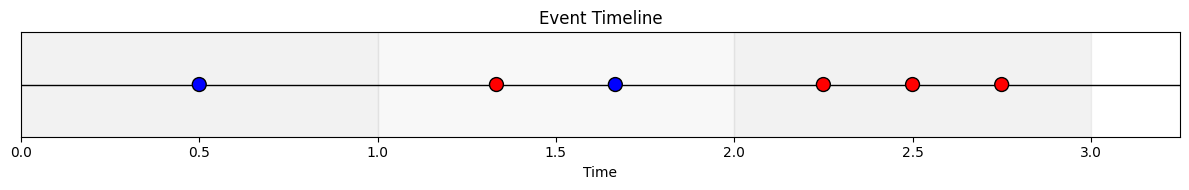

In [7]:
plot_timeline_with_colors(data, intervals)